In [1]:
from datetime import datetime

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
lakene = gis.content.search("title:lakene")[0].layers[0]
lakene.url

'https://pythonapi.playground.esri.com/server/rest/services/lakene/ImageServer'

In [5]:
# forecast = gis.content.search("title:forecast", item_type="Image Service")[0].layers[0]
# forecast.url

In [6]:
aoi = {"xmin": 556.05848110377,"ymin": 689.971763040958,"xmax": 823.166294540602,"ymax": 816.272742240958,"spatialReference": {"wkid": 54004, "latestWkid": 54004}}

Copy raster with clip_setting value

Submitted.
Executing...
CopyRaster GP Job: je935936067324f5a9d7284d4d855c6bb finished successfully.


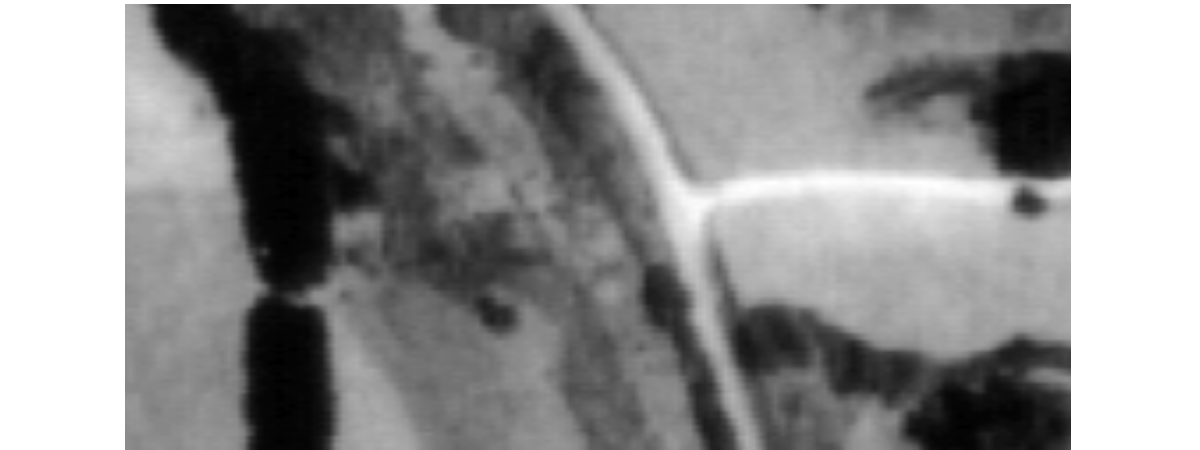

In [7]:
copy_raster_1 = arcgis.raster.analytics.copy_raster(input_raster=lakene,
                                                    output_cellsize=None,
                                                    resampling_method="NEAREST",
                                                    clip_setting={"extent":aoi},
                                                    output_name="copy_raster"+str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                    gis=gis)

copy_raster_1.layers[0]

Copy raster with BILINEAR resampling method

Submitted.
Executing...
CopyRaster GP Job: jc3fcdd1ddd6045e58ca5b3c68d5e2dc1 finished successfully.


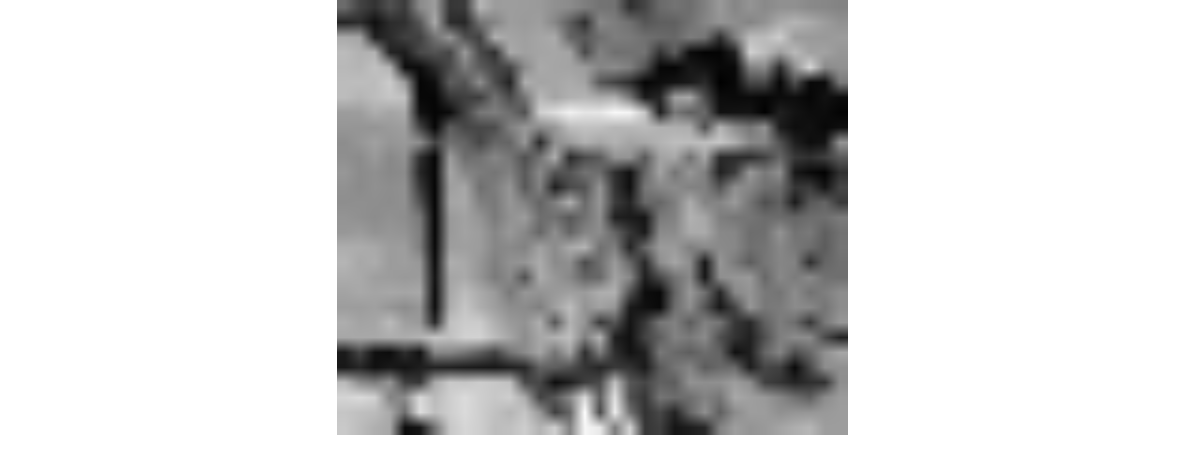

In [8]:
copy_raster_2 = arcgis.raster.analytics.copy_raster(input_raster=lakene,
                                                    resampling_method="BILINEAR",
                                                    output_cellsize={"x" : 15, "y" : 15},
                                                    output_name="copyraster"+str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                    context={"outSR":{"wkid":4326}},
                                                    gis=gis)
copy_raster_2.layers[0]

Copy raster with environment variable out_spatial_reference and 'CUBIC' resampling method

Submitted.
Executing...
CopyRaster GP Job: j9fe7c35a03a54c7ca42c579c1efbd297 finished successfully.


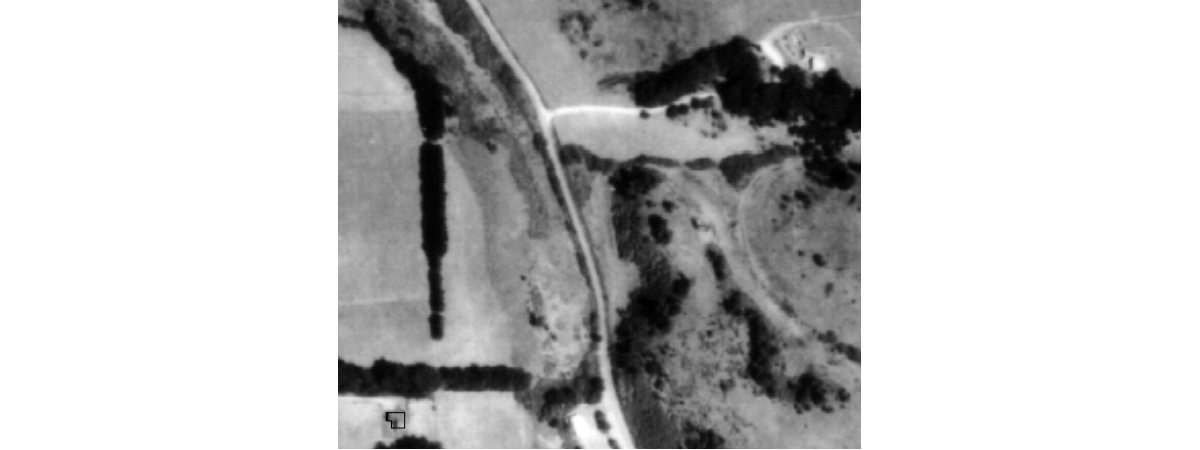

In [9]:
arcgis.env.out_spatial_reference = 4326
copy_raster_3 = arcgis.raster.analytics.copy_raster(input_raster=lakene,
                                                    resampling_method="CUBIC",
                                                    output_cellsize={"x" : 1, "y" : 1},
                                                    output_name="copyraster"+str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                    future=True,
                                                    gis=gis)
copy_raster_3.result().layers[0]

In [10]:
arcgis.env.out_spatial_reference = None

Copy Mdim Raster with process_as_multidimensional and build_transpose as True - Not Supported in 10.7.1

In [11]:
# copy_raster_4 = arcgis.raster.analytics.copy_raster(input_raster=forecast,
#                                                     resampling_method="NEAREST",
#                                                     output_name="copyraster_"+str(datetime.now().strftime('%Y%m%d%H%M%S')),
#                                                     process_as_multidimensional=True, 
#                                                     build_transpose=True,
#                                                     future=True,
#                                                     gis=gis)
# copy_raster_4.result().layers[0]

<h4> Clean Up

In [12]:
copy_raster_1.delete()

True

In [13]:
copy_raster_2.delete()

True

In [14]:
copy_raster_3.result().delete()

True

In [15]:
#copy_raster_4.result().delete()